## DepMap RNA Expression — `2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv`

1,495 cancer cell lines × 53,961 genes, already `log2(TPM+1)` scaled — the main gene expression source in the pipeline. Row index (`Unnamed: 0`) holds DepMap `ProfileID` (`PR-...`), not a cell line name; bridge to `ModelID` via `8_DepMap_OmicsProfiles.csv`. Column headers are `SYMBOL (ENSG...)` — use regex to extract the Ensembl ID if needed.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
%%time
df = pd.read_csv(ini.df2)

CPU times: total: 29 s
Wall time: 29.8 s


In [3]:
df.shape

(1495, 53962)

In [4]:
df.head()

,Unnamed: 0,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419),SCYL3 (ENSG00000000457),C1orf112 (ENSG00000000460),FGR (ENSG00000000938),CFH (ENSG00000000971),FUCA2 (ENSG00000001036),GCLC (ENSG00000001084),...,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723,ENSG00000288724,ENSG00000288725
0,PR-AdBjpG,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,0.000000,0.536053,0.000000,0.028569,0.176323,0.992768,2.797013,0.000000,0.0,0.000000
1,PR-I2AzwG,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,...,0.000000,0.879706,0.000000,0.014355,0.014355,0.432959,2.972693,0.056584,0.0,0.070389
2,PR-5ekAAC,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,0.028569,0.000000,0.084064,0.000000,0.097611,0.367371,1.695994,0.084064,0.0,0.000000
3,PR-I21681,5.085340,0.000000,7.154211,2.545968,3.084064,0.000000,5.868390,6.165309,4.489928,...,0.000000,0.000000,0.070389,0.000000,0.176323,0.411426,3.921246,0.028569,0.0,0.000000
4,PR-i9DRP1,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,...,0.000000,0.000000,0.201634,0.028569,0.137504,0.678072,4.418190,0.000000,0.0,0.000000


In [5]:
print(df.head())

  Unnamed: 0  TSPAN6 (ENSG00000000003)  TNMD (ENSG00000000005)  \
0  PR-AdBjpG                  4.331992                0.000000   
1  PR-I2AzwG                  4.567424                0.584963   
2  PR-5ekAAC                  3.150560                0.000000   
3  PR-I21681                  5.085340                0.000000   
4  PR-i9DRP1                  6.729417                0.000000   

   DPM1 (ENSG00000000419)  SCYL3 (ENSG00000000457)  \
0                7.364660                 2.792855   
1                7.106641                 2.543496   
2                7.379118                 2.333424   
3                7.154211                 2.545968   
4                6.537917                 2.456806   

   C1orf112 (ENSG00000000460)  FGR (ENSG00000000938)  CFH (ENSG00000000971)  \
0                    4.471187               0.028569               1.226509   
1                    3.504620               0.000000               0.189034   
2                    4.228049            

### Clean headers and rename index
The index column holds DepMap ProfileIDs; gene columns are `SYMBOL (ENSGXXXXXXXX)` — we extract just the Ensembl ID.

In [6]:
import re
df = df.rename(columns={"Unnamed: 0": "ProfileID"}).set_index("ProfileID")

def extract_ensg(col):
    m = re.search(r"(ENSG\d+)", col)
    return m.group(1) if m else col

df.columns = [extract_ensg(c) for c in df.columns]
print(f"Shape: {df.shape}  (rows=profiles, cols=genes)")


Shape: (1495, 53961)  (rows=profiles, cols=genes)


### Distribution of expression values
Already log2(TPM+1) — should be approximately normal, centred ~3-5.

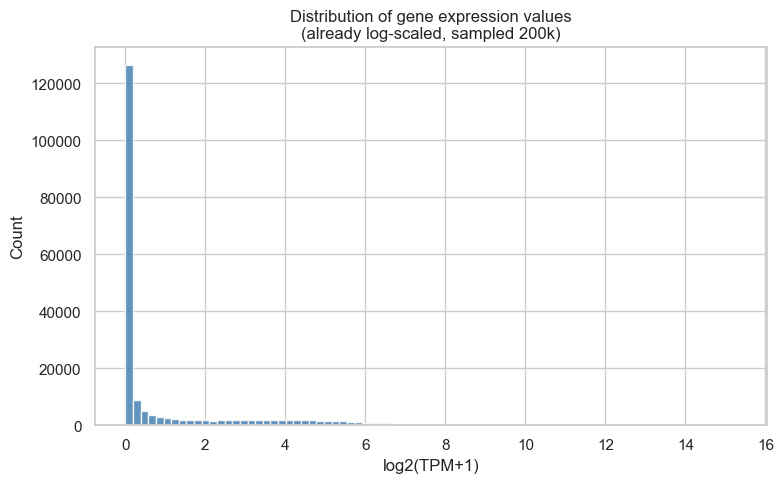

Mean: 1.08  Std: 1.97  Zeros: 49.8%


In [7]:
np.random.seed(42)
flat = df.values.flatten()
flat = flat[~np.isnan(flat)]
sample = np.random.choice(flat, min(200_000, len(flat)), replace=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sample, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("log2(TPM+1)"); ax.set_ylabel("Count")
ax.set_title("Distribution of gene expression values\n(already log-scaled, sampled 200k)")
plt.tight_layout(); plt.show()
print(f"Mean: {sample.mean():.2f}  Std: {sample.std():.2f}  Zeros: {(flat==0).mean()*100:.1f}%")


### Per-cell-line mean expression
Shows whether some profiles have systematically higher/lower expression — a potential batch effect indicator.

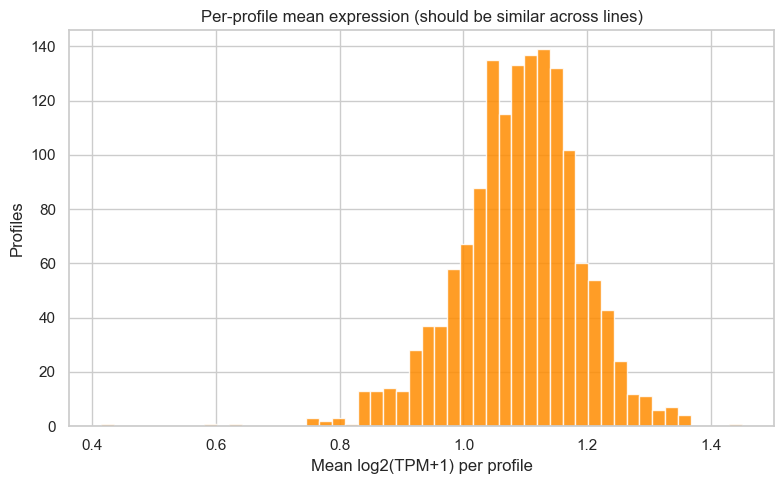

In [8]:
row_means = df.mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(row_means, bins=50, color="darkorange", edgecolor="white", alpha=0.85)
ax.set_xlabel("Mean log2(TPM+1) per profile"); ax.set_ylabel("Profiles")
ax.set_title("Per-profile mean expression (should be similar across lines)")
plt.tight_layout(); plt.show()


### Top 500 most variable genes
High-variance genes distinguish cell lines from each other — the most useful features for PCA and modelling.

Computing gene variance across 1,495 profiles...


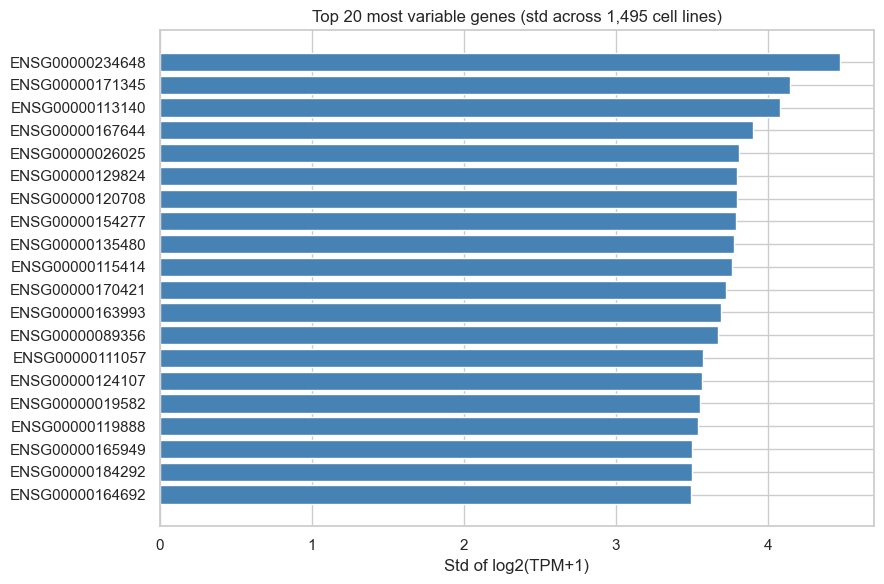

In [9]:
print("Computing gene variance across 1,495 profiles...")
gene_std = df.std()
top500 = gene_std.nlargest(500).index

top20 = gene_std.nlargest(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color="steelblue")
ax.set_title("Top 20 most variable genes (std across 1,495 cell lines)")
ax.set_xlabel("Std of log2(TPM+1)")
plt.tight_layout(); plt.show()


### PCA of cell lines (top 500 variable genes)
Each dot = one cancer cell line. Nearby dots have similar gene expression profiles. Clusters often correspond to cancer types.

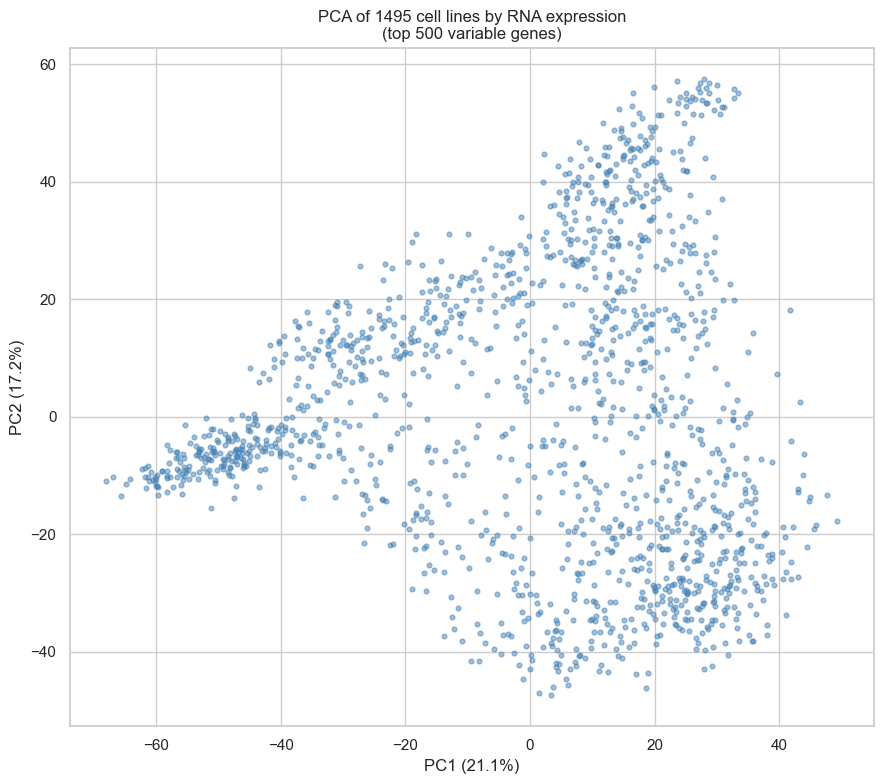

In [10]:
X = df[top500].values
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=12, color="steelblue")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title(f"PCA of {df.shape[0]} cell lines by RNA expression\n(top 500 variable genes)")
plt.tight_layout(); plt.show()


### Zero-value analysis
Zeros mean the gene was not detected. We check this per gene and per cell line.

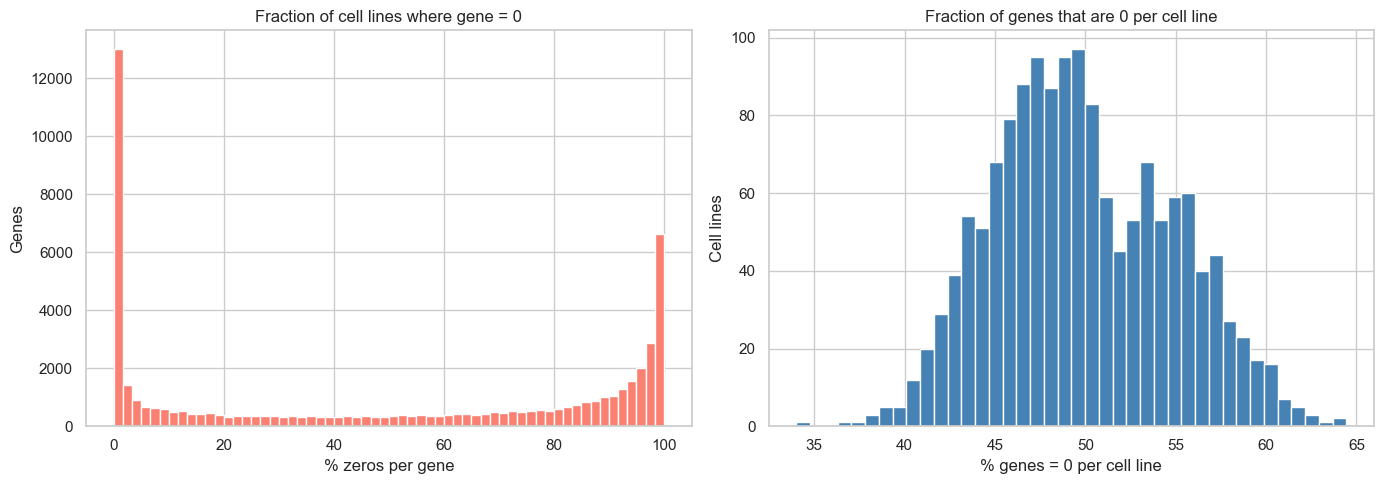

Genes with >50% zeros: 27912


In [11]:
zero_per_gene = (df == 0).mean()
zero_per_line = (df == 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(zero_per_gene * 100, bins=60, color="salmon", edgecolor="white")
axes[0].set_xlabel("% zeros per gene"); axes[0].set_ylabel("Genes")
axes[0].set_title("Fraction of cell lines where gene = 0")

axes[1].hist(zero_per_line * 100, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("% genes = 0 per cell line"); axes[1].set_ylabel("Cell lines")
axes[1].set_title("Fraction of genes that are 0 per cell line")

plt.tight_layout(); plt.show()
print(f"Genes with >50% zeros: {(zero_per_gene > 0.5).sum()}")


### Key findings

In [12]:
print("=== DepMap RNA Expression (wide format) ===")
print(f"Profiles (cell lines) : {df.shape[0]}")
print(f"Genes                 : {df.shape[1]}")
print(f"PCA PC1+PC2 variance  : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"Genes with >50% zeros : {(zero_per_gene > 0.5).sum()}")
print(f"Top variable gene     : {gene_std.idxmax()} (std={gene_std.max():.2f})")


=== DepMap RNA Expression (wide format) ===
Profiles (cell lines) : 1495
Genes                 : 53961
PCA PC1+PC2 variance  : 38.3%
Genes with >50% zeros : 27912
Top variable gene     : ENSG00000234648 (std=4.48)


## Join Analysis — how this table connects to the others

df2 uses DepMap **ProfileID** (`PR-...`) as its row index — NOT a cell line name.
It must go through df8 to get a `ModelID`, then to df9 for biological metadata.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df2 | row index (ProfileID) | df8 | `ProfileID` (filter `Datatype=='rna'`) | 1:1 | bridge table |
| df8 | `ModelID` | df9 | `DepMap_ID` | 1:1 | adds lineage, disease metadata |
| df2 via df9 | ModelID | df5 | `ModelID` | 1:many | RNA + fusions per cell line |
| df2 via df9 | ModelID | df6 via df8 | ProfileID→ModelID | 1:many | RNA + mutations |
| df2 via df9 | ModelID | df14 | `ModelID` | 1:1 | RNA + genome instability |

**Why this matters biologically:** After resolving ProfileID → ModelID, every gene
expression row can be annotated with cancer type, tissue origin, and linked to
mutation / fusion / genome signature data. ProfileIDs that don't resolve to a
ModelID in df9 represent profiles with incomplete metadata.


In [13]:
# ── A/B: Join coverage df2 → df8 → df9 ─────────────────────────────────────
df8_ids = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage", "primary_disease"])

df2_profiles  = set(df.index)                          # df2 already has ProfileID as index
df8_rna       = df8_ids[df8_ids["Datatype"] == "rna"]
df8_rna_profs = set(df8_rna["ProfileID"])
matched_profs = df2_profiles & df8_rna_profs
lost_profs    = df2_profiles - df8_rna_profs

resolved_models = set(df8_rna[df8_rna["ProfileID"].isin(matched_profs)]["ModelID"])
df9_models      = set(df9_ids["DepMap_ID"])
matched_models  = resolved_models & df9_models
lost_models     = resolved_models - df9_models

print("=== df2 join path: ProfileID → df8(rna) → df9 ===")
print(f"df2 ProfileIDs          : {len(df2_profiles)}")
print(f"Matched in df8 (rna)    : {len(matched_profs)} ({len(matched_profs)/len(df2_profiles)*100:.1f}%)")
print(f"Lost (not in df8 rna)   : {len(lost_profs)}")
print(f"Resolved to ModelIDs    : {len(resolved_models)}")
print(f"ModelIDs in df9         : {len(matched_models)} ({len(matched_models)/len(resolved_models)*100:.1f}%)")
print(f"Lost ModelIDs (not df9) : {len(lost_models)}")
print()

# Cross-dataset overlap
df5_models  = set(pd.read_csv(ini.df5, usecols=["ModelID"])["ModelID"].dropna())
df14_models = set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna())
print(f"df2 ModelIDs also in df5  (fusions)          : {len(matched_models & df5_models)}")
print(f"df2 ModelIDs also in df14 (genome sigs)      : {len(matched_models & df14_models)}")
print(f"df2 ModelIDs in df5 AND df14 (triple overlap): {len(matched_models & df5_models & df14_models)}")


=== df2 join path: ProfileID → df8(rna) → df9 ===
df2 ProfileIDs          : 1495
Matched in df8 (rna)    : 1495 (100.0%)
Lost (not in df8 rna)   : 0
Resolved to ModelIDs    : 1479
ModelIDs in df9         : 1412 (95.5%)
Lost ModelIDs (not df9) : 67



df2 ModelIDs also in df5  (fusions)          : 1411
df2 ModelIDs also in df14 (genome sigs)      : 1371
df2 ModelIDs in df5 AND df14 (triple overlap): 1370


In [14]:
# ── C: Format check on ProfileID (row index) ────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


prof_series = pd.Series(list(df2_profiles))
fmt_check(prof_series, "ProfileID (df2 index)", prefix="PR-")
print()
# Check for any duplicates in the original file
print(f"Duplicate ProfileIDs in df2: {df.index.duplicated().sum()}")


Format check — ProfileID (df2 index) (n=1495 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Duplicate ProfileIDs in df2: 0


### Biological implications

ProfileIDs in df2 that have no entry in df8 (`Datatype=='rna'`) represent profiles
for which the bridge table has no record — likely data from an older DepMap release.
Those rows cannot be linked to any cancer type metadata and must be dropped or handled
separately.

The triple-overlap (df2 ∩ df5 ∩ df14) is the set of cell lines where a combined
RNA expression + gene fusion + genome instability model is possible — the richest
feature set for CellLineSelector.


In [15]:
# Biological: lineage breakdown of matched vs lost models
matched_df9 = df9_ids[df9_ids["DepMap_ID"].isin(matched_models)]
lost_df9    = df9_ids[df9_ids["DepMap_ID"].isin(lost_models)]

print("Lineage coverage of df2 ModelIDs that reach df9 (top 10):")
print(matched_df9["lineage"].value_counts().head(10).to_string())
print()
if len(lost_df9) > 0:
    print("Lineages of ModelIDs lost (resolved but not in df9):")
    print(lost_df9["lineage"].value_counts().to_string())
else:
    print("All resolved ModelIDs are present in df9 — no lineage loss at this step.")


Lineage coverage of df2 ModelIDs that reach df9 (top 10):
lineage
lung                      210
blood                     104
central_nervous_system     86
skin                       86
lymphocyte                 84
colorectal                 73
ovary                      65
breast                     63
soft_tissue                60
upper_aerodigestive        57

All resolved ModelIDs are present in df9 — no lineage loss at this step.


## Join Analysis — how this table connects to the others

df2 uses DepMap **ProfileID** (`PR-...`) as its row index — NOT a cell line name.
It must go through df8 to get a `ModelID`, then to df9 for biological metadata.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df2 | row index (ProfileID) | df8 | `ProfileID` (filter `Datatype=='rna'`) | 1:1 | bridge table |
| df8 | `ModelID` | df9 | `DepMap_ID` | 1:1 | adds lineage, disease metadata |
| df2 via df9 | ModelID | df5 | `ModelID` | 1:many | RNA + fusions per cell line |
| df2 via df9 | ModelID | df6 via df8 | ProfileID→ModelID | 1:many | RNA + mutations |
| df2 via df9 | ModelID | df14 | `ModelID` | 1:1 | RNA + genome instability |

**Why this matters biologically:** After resolving ProfileID → ModelID, every gene
expression row can be annotated with cancer type, tissue origin, and linked to
mutation / fusion / genome signature data. ProfileIDs that don't resolve to a
ModelID in df9 represent profiles with incomplete metadata.


In [16]:
# ── A/B: Join coverage df2 → df8 → df9 ─────────────────────────────────────
df8_ids = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage", "primary_disease"])

df2_profiles  = set(df.index)                          # df2 already has ProfileID as index
df8_rna       = df8_ids[df8_ids["Datatype"] == "rna"]
df8_rna_profs = set(df8_rna["ProfileID"])
matched_profs = df2_profiles & df8_rna_profs
lost_profs    = df2_profiles - df8_rna_profs

resolved_models = set(df8_rna[df8_rna["ProfileID"].isin(matched_profs)]["ModelID"])
df9_models      = set(df9_ids["DepMap_ID"])
matched_models  = resolved_models & df9_models
lost_models     = resolved_models - df9_models

print("=== df2 join path: ProfileID → df8(rna) → df9 ===")
print(f"df2 ProfileIDs          : {len(df2_profiles)}")
print(f"Matched in df8 (rna)    : {len(matched_profs)} ({len(matched_profs)/len(df2_profiles)*100:.1f}%)")
print(f"Lost (not in df8 rna)   : {len(lost_profs)}")
print(f"Resolved to ModelIDs    : {len(resolved_models)}")
print(f"ModelIDs in df9         : {len(matched_models)} ({len(matched_models)/len(resolved_models)*100:.1f}%)")
print(f"Lost ModelIDs (not df9) : {len(lost_models)}")
print()

# Cross-dataset overlap
df5_models  = set(pd.read_csv(ini.df5, usecols=["ModelID"])["ModelID"].dropna())
df14_models = set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna())
print(f"df2 ModelIDs also in df5  (fusions)          : {len(matched_models & df5_models)}")
print(f"df2 ModelIDs also in df14 (genome sigs)      : {len(matched_models & df14_models)}")
print(f"df2 ModelIDs in df5 AND df14 (triple overlap): {len(matched_models & df5_models & df14_models)}")


=== df2 join path: ProfileID → df8(rna) → df9 ===
df2 ProfileIDs          : 1495
Matched in df8 (rna)    : 1495 (100.0%)
Lost (not in df8 rna)   : 0
Resolved to ModelIDs    : 1479
ModelIDs in df9         : 1412 (95.5%)
Lost ModelIDs (not df9) : 67



df2 ModelIDs also in df5  (fusions)          : 1411
df2 ModelIDs also in df14 (genome sigs)      : 1371
df2 ModelIDs in df5 AND df14 (triple overlap): 1370


In [17]:
# ── C: Format check on ProfileID (row index) ────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


prof_series = pd.Series(list(df2_profiles))
fmt_check(prof_series, "ProfileID (df2 index)", prefix="PR-")
print()
# Check for any duplicates in the original file
print(f"Duplicate ProfileIDs in df2: {df.index.duplicated().sum()}")


Format check — ProfileID (df2 index) (n=1495 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Duplicate ProfileIDs in df2: 0


### Biological implications

ProfileIDs in df2 that have no entry in df8 (`Datatype=='rna'`) represent profiles
for which the bridge table has no record — likely data from an older DepMap release.
Those rows cannot be linked to any cancer type metadata and must be dropped or handled
separately.

The triple-overlap (df2 ∩ df5 ∩ df14) is the set of cell lines where a combined
RNA expression + gene fusion + genome instability model is possible — the richest
feature set for CellLineSelector.


In [18]:
# Biological: lineage breakdown of matched vs lost models
matched_df9 = df9_ids[df9_ids["DepMap_ID"].isin(matched_models)]
lost_df9    = df9_ids[df9_ids["DepMap_ID"].isin(lost_models)]

print("Lineage coverage of df2 ModelIDs that reach df9 (top 10):")
print(matched_df9["lineage"].value_counts().head(10).to_string())
print()
if len(lost_df9) > 0:
    print("Lineages of ModelIDs lost (resolved but not in df9):")
    print(lost_df9["lineage"].value_counts().to_string())
else:
    print("All resolved ModelIDs are present in df9 — no lineage loss at this step.")


Lineage coverage of df2 ModelIDs that reach df9 (top 10):
lineage
lung                      210
blood                     104
central_nervous_system     86
skin                       86
lymphocyte                 84
colorectal                 73
ovary                      65
breast                     63
soft_tissue                60
upper_aerodigestive        57

All resolved ModelIDs are present in df9 — no lineage loss at this step.


## Deeper dive: PCA coloured by lineage + candidate feature export

The base PCA showed structure but couldn't say whether it is *biological*. Colouring
each profile by its DepMap lineage answers that: tight, lineage-coloured clusters mean
expression carries strong tissue signal (exactly what a CellLineSelector exploits). We
also export the top-1000 highest-variance genes as a concrete candidate feature set for
the preprocessing stage.

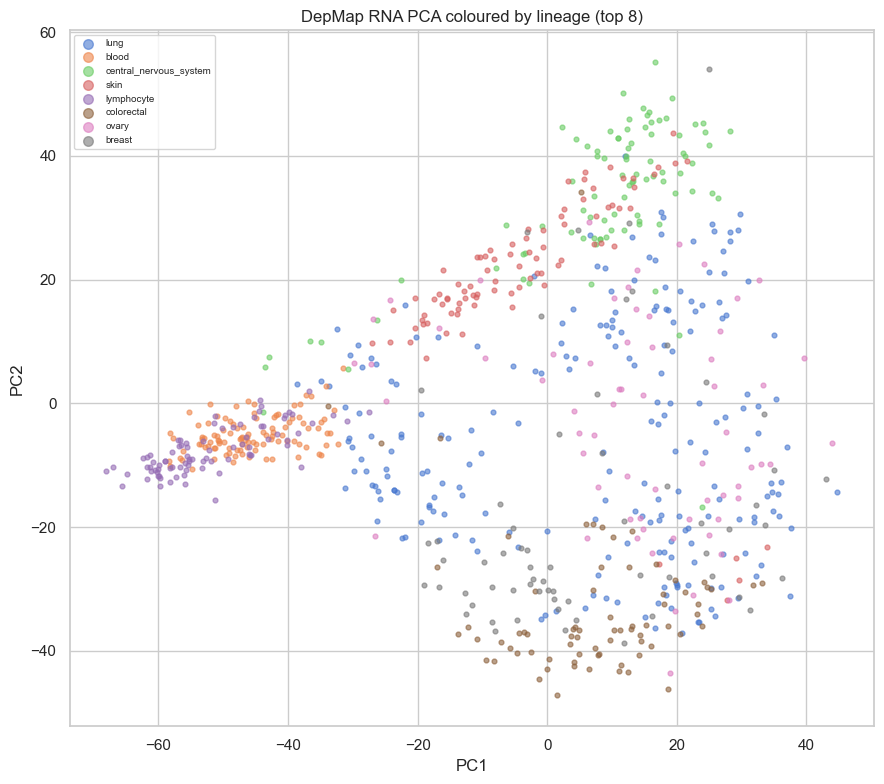

Candidate feature set for preprocessing: top-1000 variance genes
examples: ['ENSG00000234648', 'ENSG00000171345', 'ENSG00000113140', 'ENSG00000167644', 'ENSG00000026025']


In [19]:
import __init__ as ini
from sklearn.decomposition import PCA
d8 = pd.read_csv(ini.df8, usecols=["ProfileID","ModelID","Datatype"])
d9 = pd.read_csv(ini.df9, usecols=["DepMap_ID","lineage"])
p2l = (d8[d8.Datatype=="rna"].merge(d9, left_on="ModelID", right_on="DepMap_ID")
         .drop_duplicates("ProfileID").set_index("ProfileID")["lineage"])
lins = np.array(df.index.map(p2l))
coords = PCA(n_components=2, random_state=42).fit_transform(df[top500].values)
topL = pd.Series(lins).value_counts().head(8).index
fig, ax = plt.subplots(figsize=(9,8))
for l in topL:
    m = lins == l
    ax.scatter(coords[m,0], coords[m,1], s=12, alpha=0.6, label=l)
ax.legend(fontsize=7, markerscale=2); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("DepMap RNA PCA coloured by lineage (top 8)")
plt.tight_layout(); plt.show()

top1000 = gene_std.nlargest(1000).index.tolist()
print("Candidate feature set for preprocessing: top-1000 variance genes")
print("examples:", top1000[:5])

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is the **cleanest, ready-to-use version of the "gene volume dials"** — the same idea as the HPA file, but from the **DepMap project**, already tidied and put on a friendly scale. The values are `log2(TPM+1)`, which just means *"gene activity, mathematically squashed so huge and tiny numbers sit on a comparable ruler."* Because it's already normalized and already in a one-row-per-sample table, this is the **backbone expression layer** of the whole project.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **1,495 sample profiles × ~53,961 genes**. Rows are keyed by `ProfileID` (e.g., `PR-xxxxxx`) — a *measurement-run* ID, **not** a cell-line name.
- About **52% of genes are mostly zeros** across samples (effectively switched off in most lines).
- A **PCA** (a way of compressing thousands of genes into a 2D map) showed cell lines **clustering tightly by tissue type** — proof the data carries strong, real biological signal.
- The join is **clean**: every `ProfileID` resolves to a cell line, and ~95.5% reach the DepMap master catalogue.

Next steps (preprocessing):
- **Map `ProfileID` → `ModelID`** using the OmicsProfiles bridge file (df8), then this table speaks the same ID language as everything else.
- **Trim the gene columns**: either drop the ~52% near-always-zero genes, or (better, biologically) **keep only protein-coding genes**, then keep the most *variable* genes for modeling so we focus on what distinguishes cell lines.
- **Standardize** the kept gene columns so no single gene dominates by scale alone.

Still missing in EDA:
- **Confirm the exact protein-coding gene filter list** to apply (so the column trimming is principled, not arbitrary).

### 3. Which ML approach fits this dataset
**Unsupervised for structure, and this is the primary feature source for the supervised ranking model.** The expression matrix is the main thing the system reads to decide which cell lines best match the requested include/exclude genes. Its tight tissue clustering means it will also power similarity-based ("find me lines like this") ranking.

> **Big-picture note:** This is the most complete and trustworthy expression layer, so it anchors the ~1,400-line training core (RNA + fusions + mutations + genome signatures), with proteomics / metabolomics / miRNA layered on as enrichment.